# Biodiversity in National Parks: Project Scope

## Project Goal
Analyze National Parks Service data to explore how conservation status varies across species categories and parks, and identify patterns among species that are at risk.

## Key Questions
- Which categories of species are most commonly protected or endangered?
- Are some parks associated with more observations of at-risk species?
- Do certain types of species appear more vulnerable than others?
- How do conservation status and park observations relate?

## Planned Workflow
1. Load `species_info.csv` and `observations.csv`
2. Inspect the data structure, missing values, and duplicates
3. Clean and standardize `conservation_status`
4. Join the datasets where needed
5. Summarize species counts by category, conservation status, and park
6. Create visualizations to compare patterns
7. Write conclusions and note limitations

## Scope Boundaries
To keep the project focused, this analysis will:
- use descriptive analysis rather than predictive modeling
- rely only on the provided datasets
- compare broad category-level and park-level patterns
- avoid making causal claims the data cannot support

## Success Criteria
The project will be complete when it:
- answers the main questions with tables and charts
- explains the key cleaning decisions
- presents 2–3 meaningful findings
- acknowledges important data limitations

## Risks and Possible Dead Ends
- Missing values in `conservation_status` must be handled carefully
- Observation counts do not necessarily represent population size
- Any relationship between park observations and conservation status should be treated as correlation, not causation

## 1. Load and preview the datasets
The first step is to import the two CSV files and look at a small sample of each table. This helps confirm that the files loaded correctly and clarifies the role of each dataset: `species` contains classification and conservation information, while `observations` records sightings across parks.

In [4]:
import pandas as pd

species = pd.read_csv('species_info.csv')
observations = pd.read_csv('observations.csv')

print(f"species rows/columns: {species.shape}")
print(f"observations rows/columns: {observations.shape}")

display(species.head())
display(observations.head())

species rows/columns: (5824, 4)
observations rows/columns: (23296, 3)


,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


## 2. Inspect data quality
Before analyzing trends, it is important to understand the structure of the data. In this section, the notebook checks data types, missing values, and duplicates so that later results are based on clean and consistent inputs.

In [6]:
print('Species dataset info:')
species.info()

print('\nObservations dataset info:')
observations.info()

print('\nMissing values in species:')
display(species.isna().sum().to_frame(name='missing_values'))

print('Missing values in observations:')
display(observations.isna().sum().to_frame(name='missing_values'))

print(f"Duplicate rows in species: {species.duplicated().sum()}")
print(f"Duplicate scientific names in species: {species['scientific_name'].duplicated().sum()}")
print(f"Duplicate rows in observations: {observations.duplicated().sum()}")
print(f"Duplicate scientific_name/park_name pairs in observations: {observations.duplicated(subset=['scientific_name', 'park_name']).sum()}")

Species dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB

Observations dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB

Missing values in species:


,missing_values
category,0
scientific_name,0
common_names,0
conservation_status,5633


Missing values in observations:


,missing_values
scientific_name,0
park_name,0
observations,0


Duplicate rows in species: 0
Duplicate scientific names in species: 283
Duplicate rows in observations: 15
Duplicate scientific_name/park_name pairs in observations: 1132


## 3. Clean and standardize conservation status
The `conservation_status` column contains many missing values, which would make comparisons difficult if left untreated. To keep the analysis consistent, missing entries are labeled `No Intervention`, formatting is standardized, and a new `is_protected` field is created for easier grouping.

In [7]:
species['conservation_status'] = (
    species['conservation_status']
    .fillna('No Intervention')
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
    .replace({'Species Of Concern': 'Species of Concern'})
)

species['is_protected'] = species['conservation_status'] != 'No Intervention'

print('Standardized conservation_status values:')
display(species['conservation_status'].value_counts().to_frame(name='count'))

print(f"Protected species count: {species['is_protected'].sum()}")
print(f"Not protected count: {(~species['is_protected']).sum()}")

Standardized conservation_status values:


,count
conservation_status,
No Intervention,5633
Species of Concern,161
Endangered,16
Threatened,10
In Recovery,4


Protected species count: 191
Not protected count: 5633


## 4. Combine species details with park observations
To answer questions about protection patterns across parks, the species information needs to be connected to the observation counts. The merge is performed on `scientific_name`, using a one-row-per-species lookup table to reduce duplicate inflation.

In [8]:
duplicate_check = species.groupby('scientific_name').agg(
    category_count=('category', 'nunique'),
    status_count=('conservation_status', 'nunique')
)

print(f"Scientific names with multiple rows: {(species['scientific_name'].value_counts() > 1).sum()}")
print(f"Conflicting category labels among duplicates: {(duplicate_check['category_count'] > 1).sum()}")
print(f"Conflicting conservation statuses among duplicates: {(duplicate_check['status_count'] > 1).sum()}")

species_lookup = (
    species
    .sort_values(by='is_protected', ascending=False)
    .drop_duplicates(subset='scientific_name')
)

observations_with_species = observations.merge(
    species_lookup[['scientific_name', 'category', 'conservation_status', 'is_protected']],
    on='scientific_name',
    how='left'
)

print(f"species_lookup rows: {species_lookup.shape[0]}")
print(f"merged rows/columns: {observations_with_species.shape}")
print(f"Unmatched merged rows: {observations_with_species['category'].isna().sum()}")

display(observations_with_species.head())

Scientific names with multiple rows: 274
Conflicting category labels among duplicates: 0
Conflicting conservation statuses among duplicates: 2
species_lookup rows: 5541
merged rows/columns: (23296, 6)
Unmatched merged rows: 0


,scientific_name,park_name,observations,category,conservation_status,is_protected
0,Vicia benghalensis,Great Smoky Mountains National Park,68,Vascular Plant,No Intervention,False
1,Neovison vison,Great Smoky Mountains National Park,77,Mammal,No Intervention,False
2,Prunus subcordata,Yosemite National Park,138,Vascular Plant,No Intervention,False
3,Abutilon theophrasti,Bryce National Park,84,Vascular Plant,No Intervention,False
4,Githopsis specularioides,Great Smoky Mountains National Park,85,Vascular Plant,No Intervention,False


## 5. Summarize and visualize the main patterns
With the datasets prepared, the analysis can now compare species counts by category, conservation status, and park. Tables and charts make it easier to identify which groups are most represented, which are more likely to be protected, and where observation activity is highest.

Species counts by category:


,total_species,protected_species,protected_pct
category,,,
Vascular Plant,4262,46,1.08
Bird,488,75,15.37
Nonvascular Plant,333,5,1.50
Mammal,176,30,17.05
Fish,125,11,8.80
Amphibian,79,7,8.86
Reptile,78,5,6.41


Species counts by category and conservation status:


,category,conservation_status,species_count
1,Amphibian,No Intervention,72
2,Amphibian,Species of Concern,4
3,Amphibian,Threatened,2
0,Amphibian,Endangered,1
6,Bird,No Intervention,413
7,Bird,Species of Concern,68
4,Bird,Endangered,4
5,Bird,In Recovery,3
9,Fish,No Intervention,114
10,Fish,Species of Concern,4


Observation summary by park:


,total_observations,protected_observations,unique_species,protected_share_pct
park_name,,,,
Yellowstone National Park,1443562,39035,5541,2.70
Yosemite National Park,863332,23533,5541,2.73
Bryce National Park,576025,16263,5541,2.82
Great Smoky Mountains National Park,431820,11277,5541,2.61


Most-spotted species in each park:


,park_name,scientific_name,category,observations
0,Bryce National Park,Columba livia,Bird,339
1,Great Smoky Mountains National Park,Streptopelia decaocto,Bird,256
2,Yellowstone National Park,Holcus lanatus,Vascular Plant,805
3,Yosemite National Park,Hypochaeris radicata,Vascular Plant,505


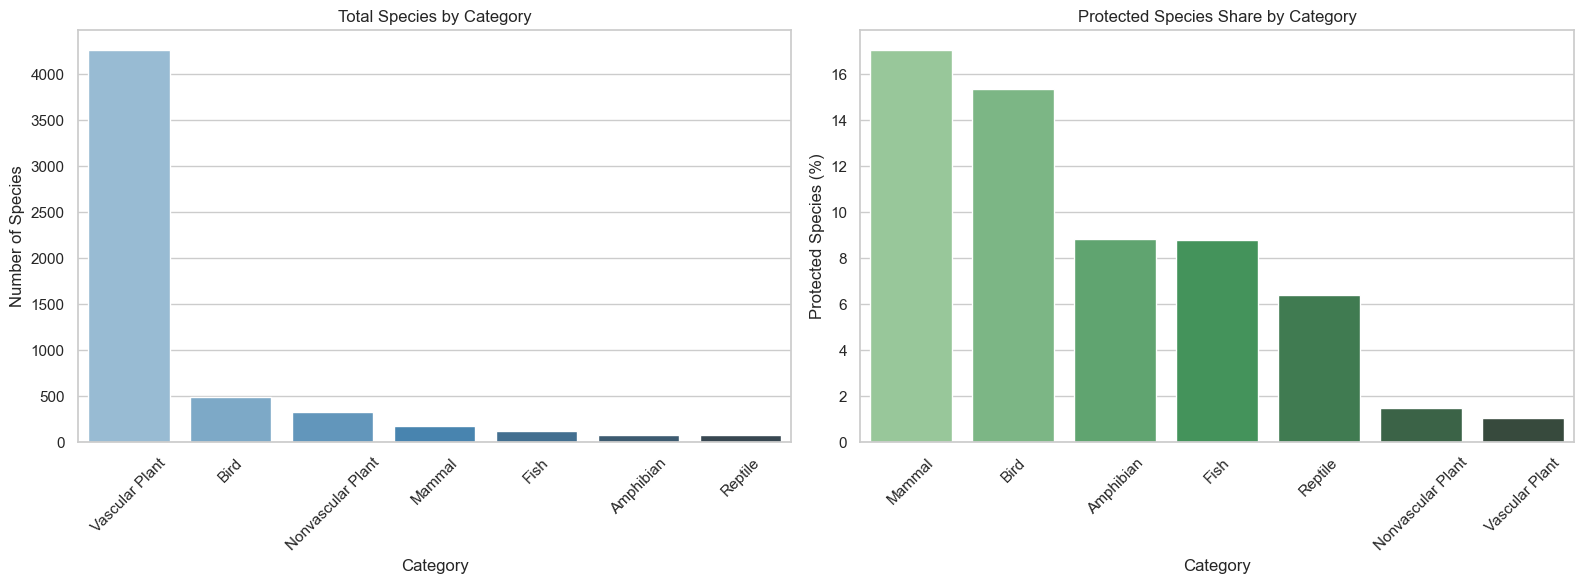

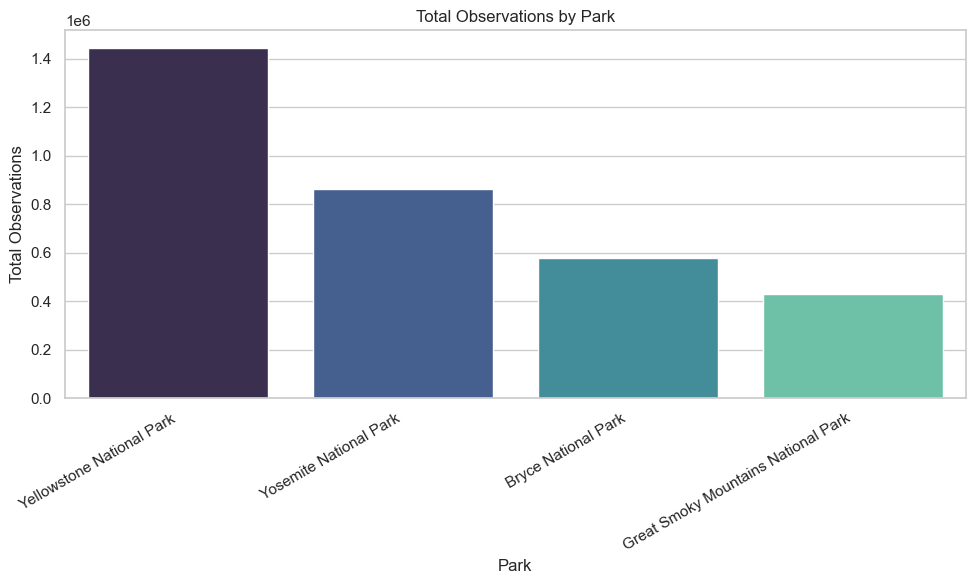

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

category_summary = (
    species_lookup.groupby('category')
    .agg(
        total_species=('scientific_name', 'nunique'),
        protected_species=('is_protected', 'sum')
    )
    .sort_values('total_species', ascending=False)
)
category_summary['protected_pct'] = (
    category_summary['protected_species'] / category_summary['total_species'] * 100
).round(2)

status_summary = (
    species_lookup.groupby(['category', 'conservation_status'])
    .size()
    .reset_index(name='species_count')
    .sort_values(['category', 'species_count'], ascending=[True, False])
)

park_summary = (
    observations_with_species.assign(
        protected_observations=lambda df: df['observations'].where(df['is_protected'], 0)
    )
    .groupby('park_name')
    .agg(
        total_observations=('observations', 'sum'),
        protected_observations=('protected_observations', 'sum'),
        unique_species=('scientific_name', 'nunique')
    )
    .sort_values('total_observations', ascending=False)
)
park_summary['protected_share_pct'] = (
    park_summary['protected_observations'] / park_summary['total_observations'] * 100
).round(2)

most_spotted_by_park = (
    observations_with_species.groupby(['park_name', 'scientific_name', 'category'])['observations']
    .sum()
    .reset_index()
    .sort_values(['park_name', 'observations'], ascending=[True, False])
    .groupby('park_name')
    .head(1)
    .reset_index(drop=True)
)

print('Species counts by category:')
display(category_summary)

print('Species counts by category and conservation status:')
display(status_summary)

print('Observation summary by park:')
display(park_summary)

print('Most-spotted species in each park:')
display(most_spotted_by_park)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=category_summary.reset_index(),
    x='category',
    y='total_species',
    ax=axes[0],
    hue='category',
    legend=False,
    palette='Blues_d'
)
axes[0].set_title('Total Species by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Species')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    data=category_summary.reset_index().sort_values('protected_pct', ascending=False),
    x='category',
    y='protected_pct',
    ax=axes[1],
    hue='category',
    legend=False,
    palette='Greens_d'
)
axes[1].set_title('Protected Species Share by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Protected Species (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=park_summary.reset_index(),
    x='park_name',
    y='total_observations',
    hue='park_name',
    legend=False,
    palette='mako'
)
plt.title('Total Observations by Park')
plt.xlabel('Park')
plt.ylabel('Total Observations')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Key insights
The exploratory analysis reveals several clear patterns in the biodiversity data:

- **Vascular plants** make up by far the largest share of recorded species, but only a very small proportion are listed as protected.
- **Mammals** and **birds** have the highest protected-species percentages, suggesting that these groups are more likely than plants to appear in at-risk categories.
- The vast majority of records fall under **`No Intervention`**, while only a relatively small number are labeled `Species of Concern`, `Endangered`, `Threatened`, or `In Recovery`.
- **Yellowstone** and **Yosemite** show the highest total observation counts, although the share of protected observations is fairly similar across all four parks.
- The most frequently observed species differ by park, showing that local biodiversity patterns are not identical from one park to another.

These results are useful for identifying broad trends, but they should be interpreted as **descriptive findings** rather than evidence of cause and effect.

## Conclusion
This project explored biodiversity data from the National Parks Service to understand how conservation status differs across species groups and parks. The analysis showed that while most species are not currently marked for intervention, protected species are more concentrated among **mammals** and **birds** than among plant categories. It also showed that **Yellowstone National Park** has the highest total number of recorded observations, followed by **Yosemite**.

Overall, the notebook demonstrates a complete data analysis workflow: loading data, checking quality, cleaning key variables, merging datasets, summarizing results, and visualizing patterns. These findings provide a strong portfolio example of how exploratory analysis can be used to turn raw environmental data into clear, evidence-based insights.

### Limitations
- Observation counts represent sightings, not total population size.
- The dataset supports **pattern detection**, not causal conclusions.
- Duplicate scientific names and limited conservation labels may simplify some real-world complexity.

### Final takeaway
The strongest takeaway from this analysis is that **risk is not evenly distributed across species categories**. Birds and mammals appear more likely to require protection, while plant groups make up most of the overall biodiversity records but a much smaller protected share.